# 🌾 Quant Trading – Backtesting Donchian Breakout
Stratégie price-driven sur 4 matières premières agricoles : KC, CC, SB, CT.

**Logique :**
- LONG si `close > highest high` des 20 derniers jours
- SHORT si `close < lowest low` des 20 derniers jours
- Exit via canal de 10 jours
- Equal weight : 25% par asset

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

from cleaning import load_all_clean
from backtesting import compute_signals, run_backtest, compute_metrics

In [2]:

COLORS = {'KC': '#6F4E37', 'CC': '#3D1C02', 'SB': '#E8A020', 'CT': '#4CAF50'}
NAMES  = {'KC': 'Arabica Coffee', 'CC': 'Cocoa', 'SB': 'Sugar', 'CT': 'Cotton'}


FILES = {
    "KC": "./data/KC.csv",
    "CC": "./data/CC.csv",
    "SB": "./data/SB.csv",
    "CT": "./data/CT.csv"
}

## 2. Chargement des données

In [3]:
data = load_all_clean(FILES)

Cleaning KC...
  9269 jours | 1989-01-03 → 2025-11-13
  Contrats utilisés : 171

Cleaning CC...
  9270 jours | 1989-01-03 → 2025-11-13
  Contrats utilisés : 169

Cleaning SB...
  9269 jours | 1989-01-03 → 2025-11-13
  Contrats utilisés : 139

Cleaning CT...
  9318 jours | 1989-01-03 → 2025-11-13
  Contrats utilisés : 135



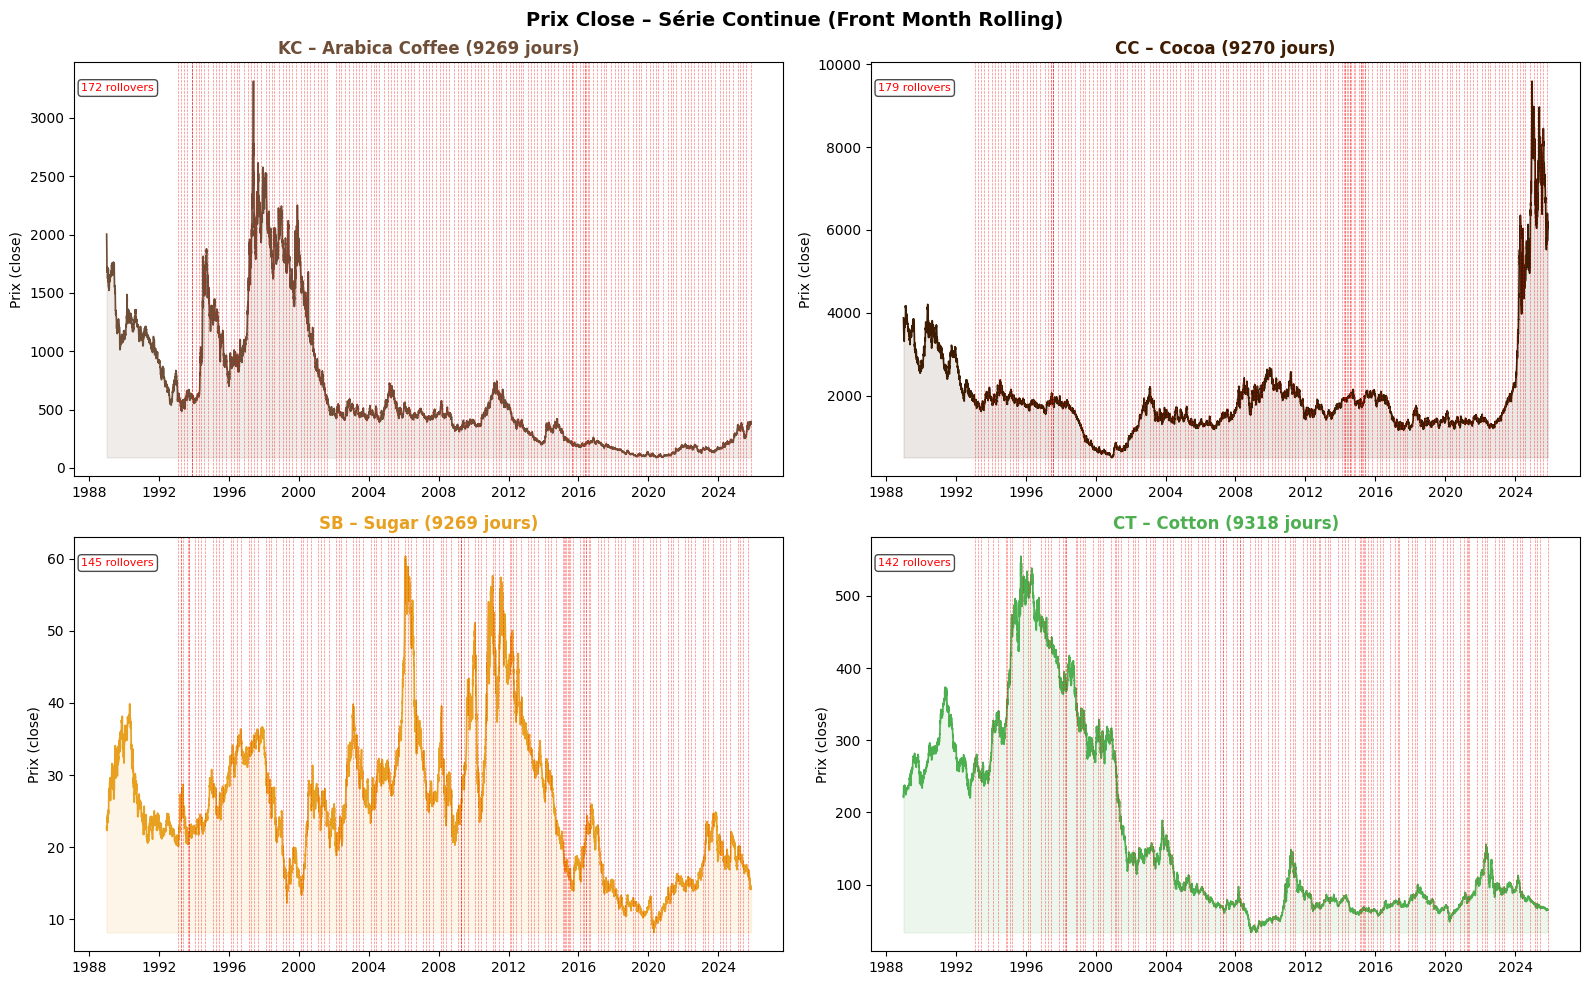

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Prix Close – Série Continue (Front Month Rolling)', fontsize=14, fontweight='bold')

for ax, asset in zip(axes.flatten(), ['KC', 'CC', 'SB', 'CT']):
    df = data[asset].copy()
    color = COLORS[asset]


    ax.plot(df['date'], df['close'], color=color, linewidth=1.2)
    ax.fill_between(df['date'], df['close'].min(), df['close'], alpha=0.1, color=color)

    # Marquer les rollovers
    rollovers = df[df['contract'] != df['contract'].shift(1)].dropna()
    for _, row in rollovers.iterrows():
        ax.axvline(row['date'], color='red', linewidth=0.5, alpha=0.5, linestyle='--')

    ax.set_title(f'{asset} – {NAMES[asset]} ({len(df)} jours)', fontweight='bold', color=color)
    ax.set_ylabel('Prix (close)')

    # Annotation rollover
    ax.text(0.01, 0.95, f'{len(rollovers)} rollovers',
            transform=ax.transAxes, fontsize=8,
            color='red', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

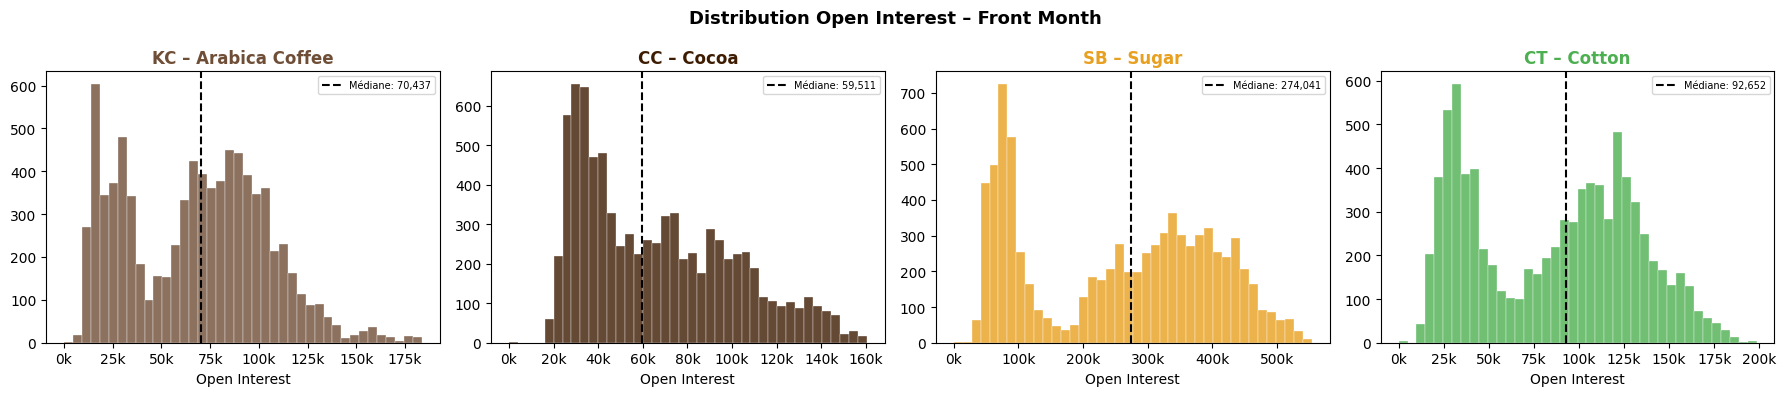

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribution Open Interest – Front Month', fontsize=13, fontweight='bold')

for ax, asset in zip(axes, ['KC', 'CC', 'SB', 'CT']):
    df = data[asset].dropna(subset=['open_interest'])
    color = COLORS[asset]

    ax.hist(df['open_interest'], bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(df['open_interest'].median(), color='black', linewidth=1.5,
               linestyle='--', label=f"Médiane: {df['open_interest'].median():,.0f}")

    ax.set_title(f'{asset} – {NAMES[asset]}', fontweight='bold', color=color)
    ax.set_xlabel('Open Interest')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

## 3. Calcul des signaux Donchian par asset
On utilise `compute_signals()` directement sur chaque asset pour visualiser les signaux.

In [6]:
ENTRY_WINDOW = 20   # canal d'entrée
EXIT_WINDOW  = 10   # canal de sortie

signals = {}
for asset, df in data.items():
    signals[asset] = compute_signals(df, entry_window=ENTRY_WINDOW, exit_window=EXIT_WINDOW)
    sig = signals[asset]
    n_long  = (sig['signal'] ==  1).sum()
    n_short = (sig['signal'] == -1).sum()
    n_flat  = (sig['signal'] ==  0).sum()
    print(f"{asset}: Long={n_long}j | Short={n_short}j | Flat={n_flat}j")

KC: Long=3019j | Short=3661j | Flat=2589j
CC: Long=3138j | Short=3177j | Flat=2955j
SB: Long=3220j | Short=3301j | Flat=2748j
CT: Long=3067j | Short=3107j | Flat=3144j


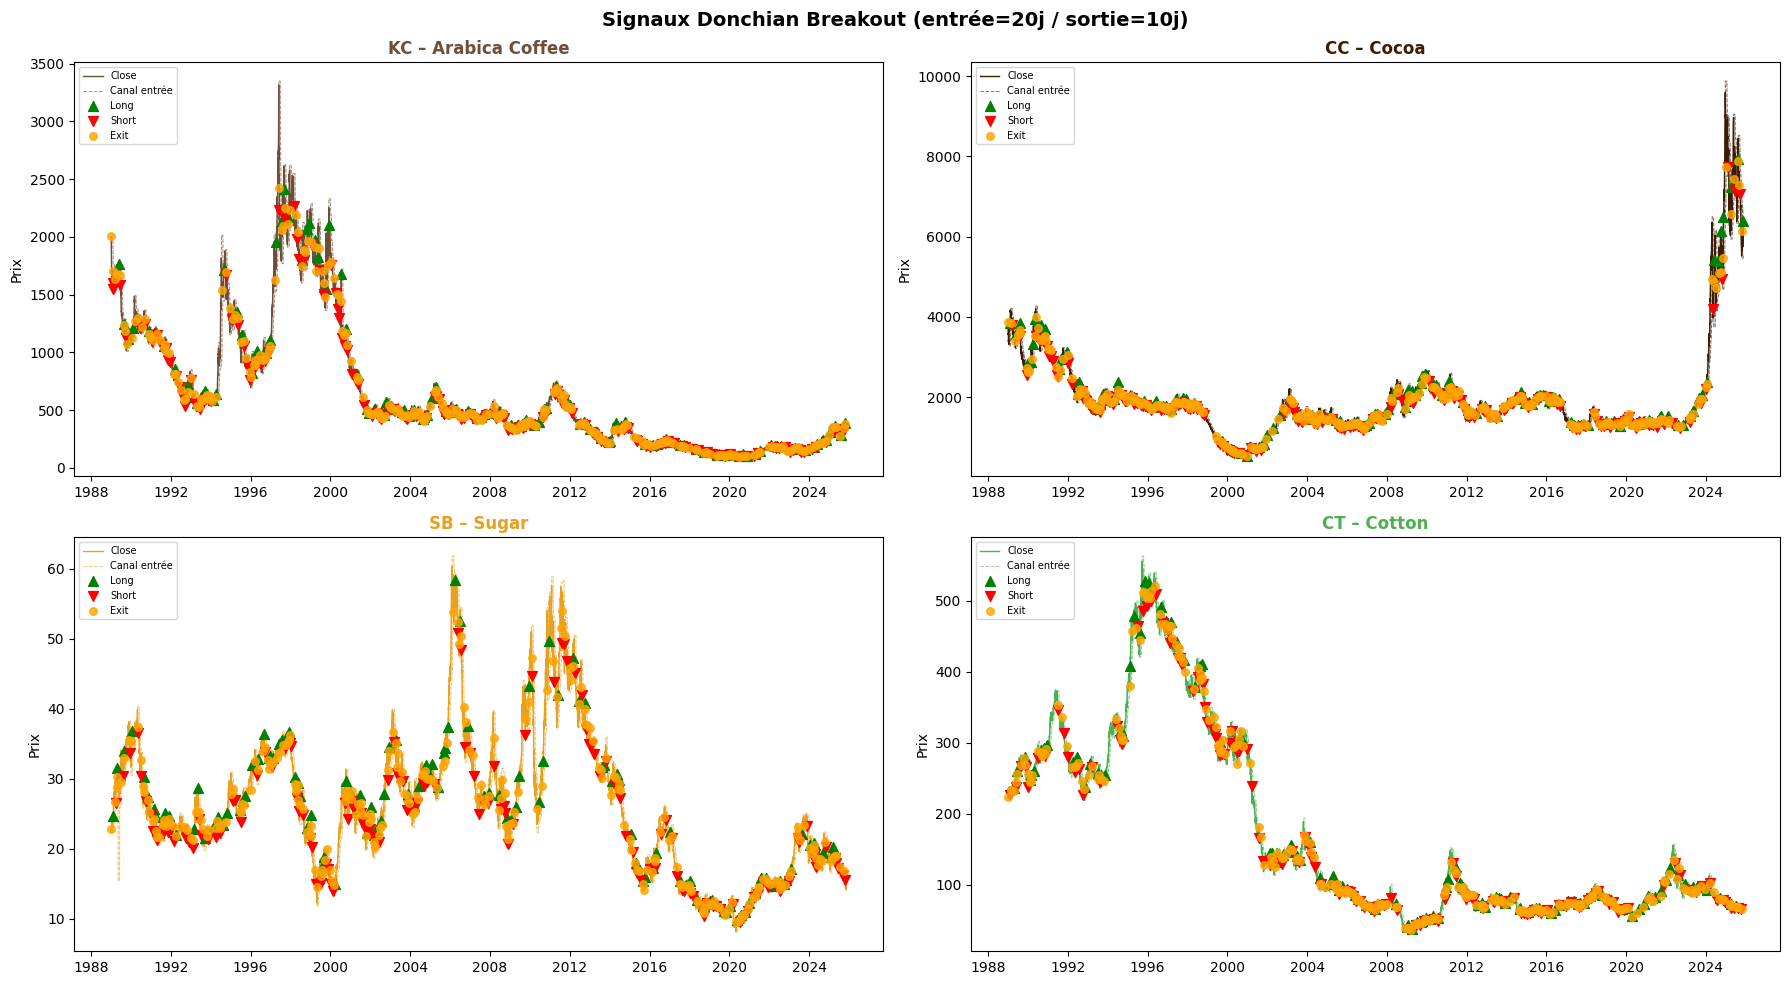

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(f'Signaux Donchian Breakout (entrée={ENTRY_WINDOW}j / sortie={EXIT_WINDOW}j)', fontsize=14, fontweight='bold')

for ax, asset in zip(axes.flatten(), ['KC', 'CC', 'SB', 'CT']):
    sig = signals[asset].copy()
    color = COLORS[asset]

    # Prix close
    ax.plot(sig['date'], sig['close'], color=color, linewidth=1.0, label='Close', zorder=2)

    # Canal Donchian
    ax.fill_between(sig['date'], sig['upper'], sig['lower'], alpha=0.08, color=color)
    ax.plot(sig['date'], sig['upper'], '--', color=color, linewidth=0.7, alpha=0.6, label='Canal entrée')
    ax.plot(sig['date'], sig['lower'], '--', color=color, linewidth=0.7, alpha=0.6)

    # Signaux d'entrée
    entries_long  = sig[(sig['signal'] == 1) & (sig['signal'].shift(1) != 1)]
    entries_short = sig[(sig['signal'] == -1) & (sig['signal'].shift(1) != -1)]
    exits         = sig[(sig['signal'] == 0) & (sig['signal'].shift(1) != 0)]

    ax.scatter(entries_long['date'],  entries_long['close'],  marker='^', color='green', s=50, zorder=5, label='Long')
    ax.scatter(entries_short['date'], entries_short['close'], marker='v', color='red',   s=50, zorder=5, label='Short')
    ax.scatter(exits['date'],         exits['close'],         marker='o', color='orange',s=30, zorder=5, label='Exit', alpha=0.8)

    ax.set_title(f'{asset} – {NAMES[asset]}', fontweight='bold', color=color)
    ax.set_ylabel('Prix')
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
result = run_backtest(
    data             = data,
    entry_window     = ENTRY_WINDOW,
    exit_window      = EXIT_WINDOW,
    transaction_cost = 0.001,   # 0.1% par trade
    initial_capital  = 100_000
)

metrics = compute_metrics(result)

print('=== Métriques Portfolio ===')
print(metrics.to_string())
print('\n=== Nombre de trades par asset ===')
print(result['trades'].to_string())

=== Métriques Portfolio ===
Période                1989-01-04 → 2025-11-13
Jours de trading                          9323
Capital initial ($)                    100,000
Capital final ($)                       17,896
Total Return (%)                         -82.1
Ann. Return (%)                          -4.54
Ann. Volatility (%)                      13.22
Sharpe Ratio                            -0.344
Sortino Ratio                           -0.503
Calmar Ratio                            -0.053
Max Drawdown (%)                        -85.04
Win Rate (%)                             47.86
Profit Factor                            0.952
Nb Trades Total                           2251

=== Nombre de trades par asset ===
KC    569
CC    617
SB    535
CT    530


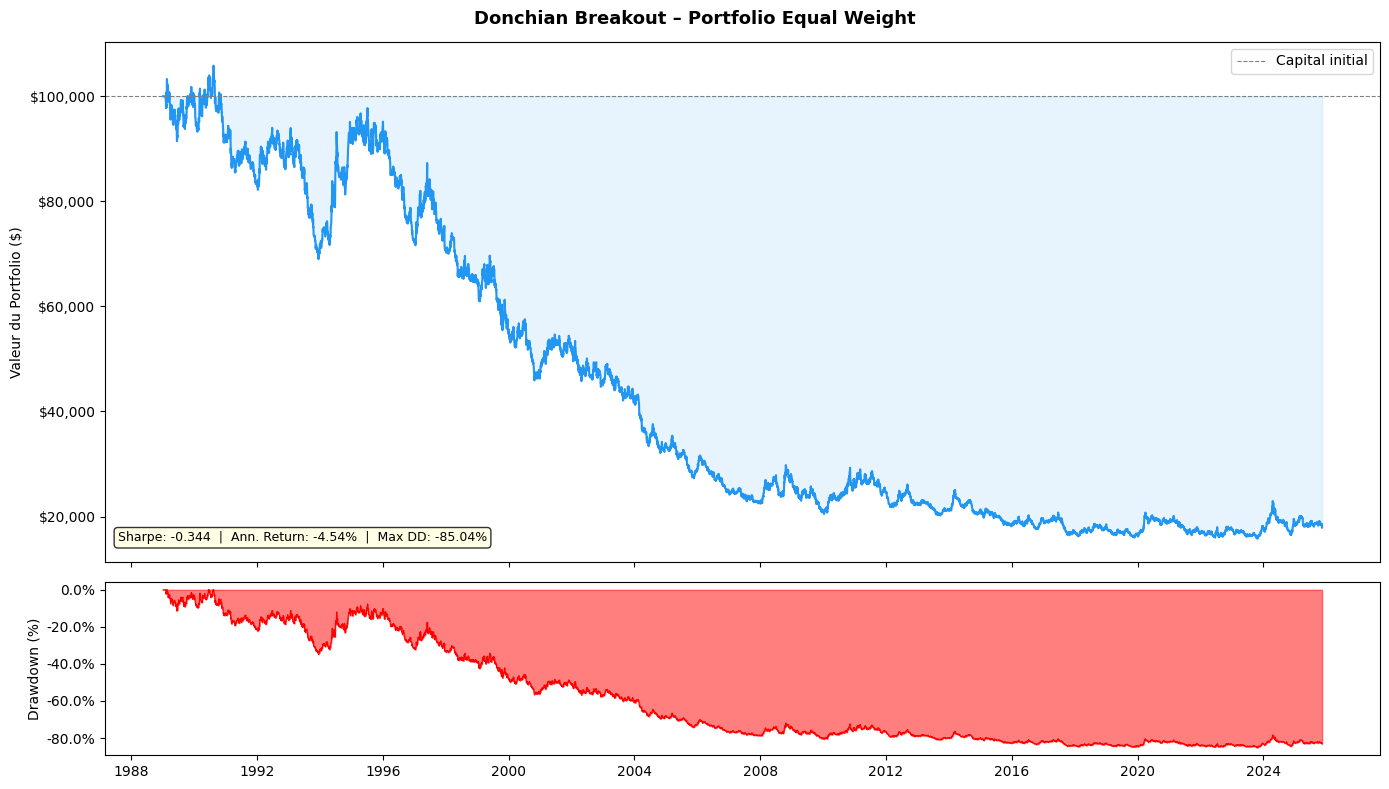

In [9]:
equity   = result['equity_curve'].dropna()
drawdown = (equity - equity.cummax()) / equity.cummax() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Donchian Breakout – Portfolio Equal Weight', fontsize=13, fontweight='bold')

# Equity curve
ax1.plot(equity.index, equity.values, color='#2196F3', linewidth=1.5)
ax1.fill_between(equity.index, equity.iloc[0], equity.values, alpha=0.1, color='#2196F3')
ax1.axhline(equity.iloc[0], color='gray', linewidth=0.8, linestyle='--', label='Capital initial')
ax1.set_ylabel('Valeur du Portfolio ($)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend()

# Annotations métriques
txt = (f"Sharpe: {metrics['Sharpe Ratio']}  |  "
       f"Ann. Return: {metrics['Ann. Return (%)']}%  |  "
       f"Max DD: {metrics['Max Drawdown (%)']}%")
ax1.text(0.01, 0.04, txt, transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Drawdown
ax2.fill_between(drawdown.index, 0, drawdown.values, color='red', alpha=0.5)
ax2.plot(drawdown.index, drawdown.values, color='red', linewidth=0.8)
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

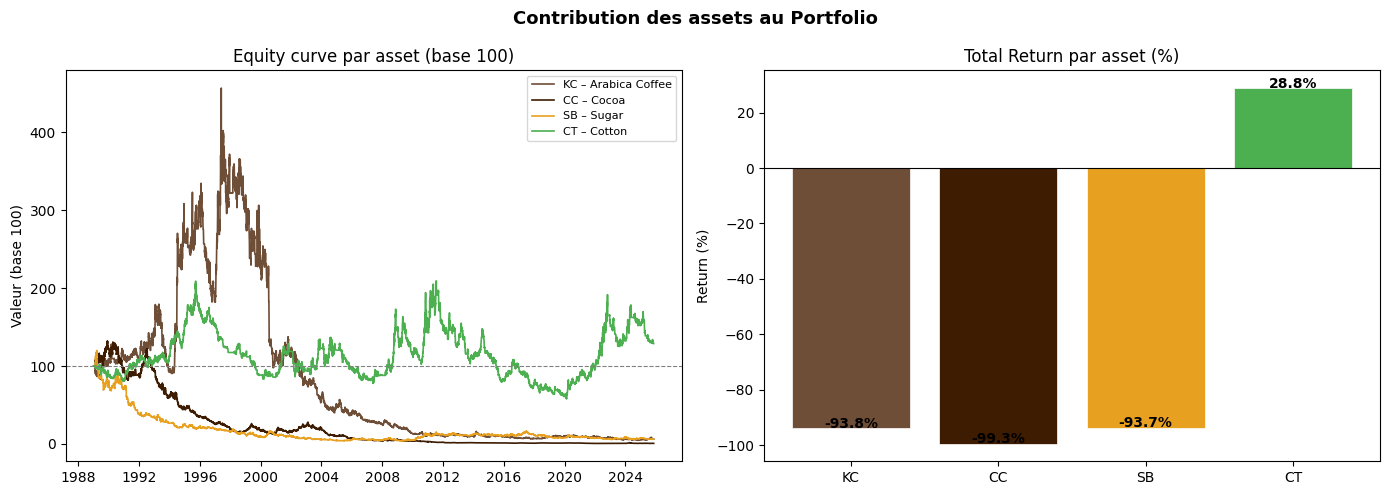

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Contribution des assets au Portfolio', fontsize=13, fontweight='bold')

# Equity curve par asset
ax1 = axes[0]
for asset in ['KC', 'CC', 'SB', 'CT']:
    asset_equity = (1 + result['returns'][asset]).cumprod() * 100
    ax1.plot(asset_equity.index, asset_equity.values,
             color=COLORS[asset], linewidth=1.2, label=f"{asset} – {NAMES[asset]}")
ax1.axhline(100, color='gray', linewidth=0.8, linestyle='--')
ax1.set_title('Equity curve par asset (base 100)')
ax1.set_ylabel('Valeur (base 100)')
ax1.legend(fontsize=8)

# Total return par asset (bar chart)
ax2 = axes[1]
total_returns = {}
for asset in ['KC', 'CC', 'SB', 'CT']:
    r = result['returns'][asset].dropna()
    total_returns[asset] = round((1 + r).prod() - 1, 4) * 100

assets = list(total_returns.keys())
values = list(total_returns.values())
bar_colors = [COLORS[a] for a in assets]
bars = ax2.bar(assets, values, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Total Return par asset (%)')
ax2.set_ylabel('Return (%)')

plt.tight_layout()
plt.show()

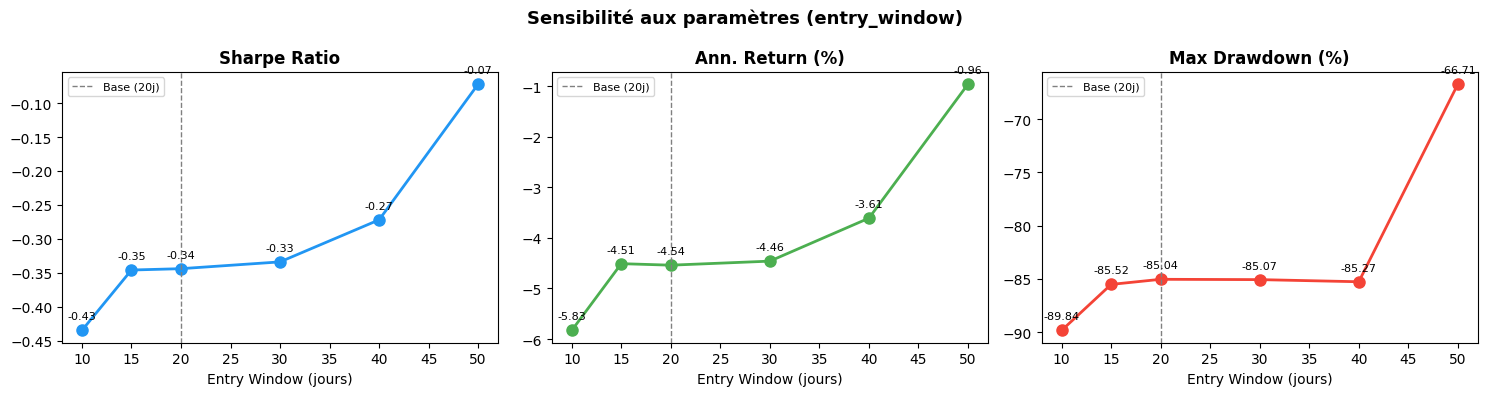

In [11]:
entry_windows = [10, 15, 20, 30, 40, 50]
sharpes = []
returns = []
drawdowns = []

for ew in entry_windows:
    res = run_backtest(data, entry_window=ew, exit_window=ew//2)
    m = compute_metrics(res)
    sharpes.append(m['Sharpe Ratio'])
    returns.append(m['Ann. Return (%)'])
    drawdowns.append(m['Max Drawdown (%)'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sensibilité aux paramètres (entry_window)', fontsize=13, fontweight='bold')

for ax, values, title, color in zip(
    axes,
    [sharpes, returns, drawdowns],
    ['Sharpe Ratio', 'Ann. Return (%)', 'Max Drawdown (%)'],
    ['#2196F3', '#4CAF50', '#F44336']
):
    ax.plot(entry_windows, values, marker='o', color=color, linewidth=2, markersize=8)
    ax.axvline(ENTRY_WINDOW, color='gray', linestyle='--', linewidth=1, label=f'Base ({ENTRY_WINDOW}j)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Entry Window (jours)')
    ax.legend(fontsize=8)
    for x, y in zip(entry_windows, values):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## Optimisation – Grid Search
On teste toutes les combinaisons `entry_window` ∈ [60, 150] et `exit_window` ∈ [10, 80].

Pour chaque combinaison : **Sharpe Ratio moyen sur les 4 assets**.

> ⚠️ Chaque asset est backtesté indépendamment sur toute sa période disponible (pas d'intersection de dates).

In [12]:
from backtesting import backtest_asset

def grid_search(data, entry_range, exit_range):
    """
    Teste toutes les combinaisons entry/exit.
    Pour chaque combinaison, calcule la moyenne du Sharpe sur les 4 assets.
    Retourne un DataFrame trié par Sharpe décroissant.
    """
    results = []

    for ew in entry_range:
        for xw in exit_range:
            if xw >= ew:   # exit doit être plus court que entry
                continue

            sharpes, ann_rets, drawdowns = [], [], []

            for asset, df in data.items():
                res    = backtest_asset(df, entry_window=ew, exit_window=xw)
                r      = res['net_return'].dropna()
                if len(r) < 200:
                    continue

                equity = (1 + r).cumprod()
                ann    = equity.iloc[-1] ** (252 / len(r)) - 1
                vol    = r.std() * np.sqrt(252)
                sharpe = ann / vol if vol > 0 else np.nan
                dd     = ((equity - equity.cummax()) / equity.cummax()).min()

                sharpes.append(sharpe)
                ann_rets.append(ann)
                drawdowns.append(dd)

            results.append({
                'entry_window':   ew,
                'exit_window':    xw,
                'sharpe':         round(np.nanmean(sharpes), 3),
                'ann_return (%)': round(np.nanmean(ann_rets) * 100, 2),
                'max_dd (%)':     round(np.nanmean(drawdowns) * 100, 2),
            })

    return pd.DataFrame(results).sort_values('sharpe', ascending=False).reset_index(drop=True)


print('Lancement du grid search...')
opt_results = grid_search(
    data,
    entry_range = range(60, 151, 10),
    exit_range  = range(10, 81, 10)
)

best_entry = int(opt_results.iloc[0]['entry_window'])
best_exit  = int(opt_results.iloc[0]['exit_window'])

print(f'\n✅ Meilleurs paramètres : entry_window={best_entry} | exit_window={best_exit}')
print(f'\nTop 10 combinaisons :')
print(opt_results.head(10).to_string(index=False))

Lancement du grid search...

✅ Meilleurs paramètres : entry_window=110 | exit_window=50

Top 10 combinaisons :
 entry_window  exit_window  sharpe  ann_return (%)  max_dd (%)
          110           50   0.047            0.63      -73.32
          120           50   0.042            0.72      -73.54
          100           50   0.032            0.47      -77.35
          110           60   0.030            0.24      -75.15
          120           60   0.029            0.41      -75.42
          130           50   0.022            0.30      -76.89
          110           80   0.022            0.22      -79.14
          120           70   0.019            0.14      -77.41
          120           80   0.018            0.22      -78.90
          100           60   0.018            0.10      -77.05


                    Base (entry=20, exit=10) Optimisé (entry=110, exit=50)
Période              1989-01-04 → 2025-11-13       1989-01-04 → 2025-11-13
Jours de trading                        9323                          9323
Capital initial ($)                  100,000                       100,000
Capital final ($)                     17,896                       277,960
Total Return (%)                       -82.1                        177.96
Ann. Return (%)                        -4.54                           2.8
Ann. Volatility (%)                    13.22                         13.38
Sharpe Ratio                          -0.344                         0.209
Sortino Ratio                         -0.503                         0.293
Calmar Ratio                          -0.053                         0.071
Max Drawdown (%)                      -85.04                        -39.63
Win Rate (%)                           47.86                         48.96
Profit Factor            

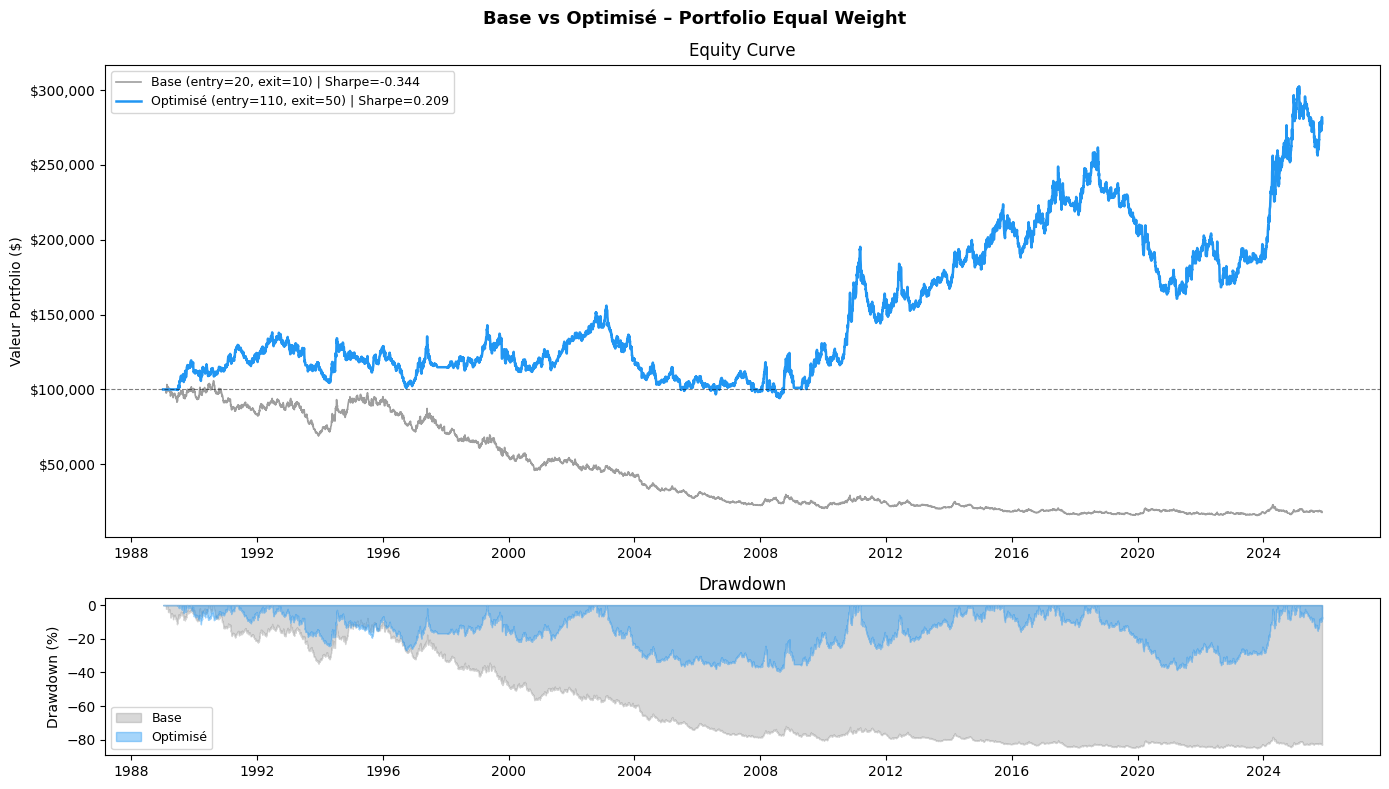

In [ ]:
result_best  = run_backtest(data, entry_window=best_entry, exit_window=best_exit)
metrics_best = compute_metrics(result_best)

# Tableau comparatif
comparison = pd.DataFrame({
    f'Base (entry=20, exit=10)':                                      metrics,
    f'Optimisé (entry={best_entry}, exit={best_exit})':               metrics_best,
})
print(comparison.to_string())

# Equity curves
eq_base = result['equity_curve'].dropna()
eq_best = result_best['equity_curve'].dropna()
dd_base = (eq_base - eq_base.cummax()) / eq_base.cummax() * 100
dd_best = (eq_best - eq_best.cummax()) / eq_best.cummax() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False,
                                gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Base vs Optimisé – Portfolio Equal Weight', fontsize=13, fontweight='bold')

ax1.plot(eq_base.index, eq_base.values, color='#9E9E9E', linewidth=1.2,
         label=f'Base (entry=20, exit=10) | Sharpe={metrics["Sharpe Ratio"]}')
ax1.plot(eq_best.index, eq_best.values, color='#2196F3', linewidth=1.8,
         label=f'Optimisé (entry={best_entry}, exit={best_exit}) | Sharpe={metrics_best["Sharpe Ratio"]}')
ax1.axhline(100_000, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_ylabel('Valeur Portfolio ($)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.set_title('Equity Curve')

ax2.fill_between(dd_base.index, 0, dd_base.values, alpha=0.3, color='gray',    label='Base')
ax2.fill_between(dd_best.index, 0, dd_best.values, alpha=0.4, color='#2196F3', label='Optimisé')
ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=9)
ax2.set_title('Drawdown')

plt.tight_layout()
plt.show()